**Постановка задачи**

| Шаг | Задача | Метод |
|-----|--------|-------|
| 1 | **Формирование задач** — откуда/куда/сколько мусора | LP транспортная задача |
| 2 | **GAP** — какие задачи берёт каждый автомобиль | Lagrangean Relaxation (Fisher, Jaikumar, Van Wassenhove 1986) |
| 3 | **VRP** — оптимальный маршрут для каждого автомобиля | Nearest Neighbour + 2-opt (Laporte 2009) |

**Метрика**: суммарные тонна·км = Σ (масса задачи × длина маршрута задачи)

**Ограничения автомобиля**: лимит км/день и лимит часов смены.

Сравним с алгоритмом, который изначально предоставили (Игорь кидал в чат)

Настраиваем пути

In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from __future__ import annotations

import json
import sys
from copy import deepcopy
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from tqdm.auto import tqdm

def find_repo_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / "simple_solver.py").exists() and (cand / "data").exists():
            return cand
    raise RuntimeError("Repo root not found. Убедитесь что ноутбук лежит рядом с simple_solver.py")


NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = find_repo_root(NOTEBOOK_DIR)

for p in [str(REPO_ROOT), str(REPO_ROOT / "data"), str(NOTEBOOK_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

import simple_solver_components as core
from dataset import dataset_from_dict
from gap_vrp_solver import (
    run_gap_vrp,
    run_baseline_greedy,
    compare_methods,
    generate_tasks_lp,
    generate_tasks_greedy,
    build_vrp_route,
    select_agents_subset,
    SolverResult,
)

print("✓ Импорты успешны")
print(f"  Репозиторий: {REPO_ROOT}")
print(f"  Ноутбук:     {NOTEBOOK_DIR}")

c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Импорты успешны
  Репозиторий: C:\Users\Пользователь\Downloads\realistic_spb_real_notebook_data\realistic_spb_real_notebook_data
  Ноутбук:     C:\Users\Пользователь\Downloads\realistic_spb_real_notebook_data\realistic_spb_real_notebook_data\data


Загружаем датасет

In [ ]:
DATASET_CANDIDATES = [
    REPO_ROOT / "data" / "dataset_real_spb_ready.json",
    NOTEBOOK_DIR / "data" / "dataset.json",
    REPO_ROOT / "data" / "realistic_spb_sandbox_notebook_data" / "data" / "dataset_real_spb_ready.json",
    REPO_ROOT / "data" / "realistic_spb_full_tz" / "dataset_full_tz.json",
]

DATASET_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        f"Датасет не найден. Проверьте пути:\n" + "\n".join(str(p) for p in DATASET_CANDIDATES)
    )

print(f"✓ Датасет найден: {DATASET_PATH}")

base_payload = json.loads(DATASET_PATH.read_text(encoding="utf-8"))
dataset      = dataset_from_dict(base_payload)
# dataset.validate()

nodes       = dataset.graph.nodes
mno_nodes   = [n for n in nodes.values() if n.kind == "mno"]
obj_nodes   = [n for n in nodes.values() if n.kind.startswith("object")]
depot_nodes = [n for n in nodes.values() if n.kind == "depot"]

print(f"\n{'─'*50}")
print(f"  Узлов в графе:         {len(nodes)}")
print(f"  Рёбер в графе:         {len(dataset.graph.edges)}")
print(f"  Источники (MNO):       {len(mno_nodes)}")
print(f"  Объекты (стоки):       {len(obj_nodes)}")
print(f"  Депо:                  {len(depot_nodes)}")
print(f"  Автомобилей (агентов): {len(dataset.fleet.agents)}")
print(f"  Задач в датасете:      {len(dataset.tasks)}")
total_mass = sum(t.mass_tons for t in dataset.tasks)
print(f"  Суммарный мусор:       {total_mass:.2f} т")
print(f"{'─'*50}")

from collections import Counter
vtype_cnt = Counter(a.vehicle_type for a in dataset.fleet.agents.values())
print("\nТипы автомобилей:")
for vtype, cnt in sorted(vtype_cnt.items()):
    print(f"  {vtype}: {cnt} шт.")

✓ Датасет найден: C:\Users\Пользователь\Downloads\realistic_spb_real_notebook_data\realistic_spb_real_notebook_data\data\dataset_real_spb_ready.json

──────────────────────────────────────────────────
  Узлов в графе:         46730
  Рёбер в графе:         127100
  Источники (MNO):       216
  Объекты (стоки):       9
  Депо:                  4
  Автомобилей (агентов): 626
  Задач в датасете:      220
  Суммарный мусор:       72.24 т
──────────────────────────────────────────────────

Типы автомобилей:
  VT_A: 80 шт.
  VT_AB: 254 шт.
  VT_ABD: 45 шт.
  VT_AD: 53 шт.
  VT_C: 176 шт.
  VT_CD: 18 шт.


Ограничение числа агентов для отладки

In [3]:
# Укажите либо список agent_id, либо число первых агентов из датасета.
# Если оба параметра отключены, используются все агенты.
SELECTED_AGENT_IDS = None
MAX_AGENTS = 5

if SELECTED_AGENT_IDS is not None or MAX_AGENTS is not None:
    dataset, base_payload = select_agents_subset(
        dataset,
        base_payload,
        selected_agent_ids=SELECTED_AGENT_IDS,
        max_agents=MAX_AGENTS,
    )

nodes       = dataset.graph.nodes
mno_nodes   = [n for n in nodes.values() if n.kind == "mno"]
obj_nodes   = [n for n in nodes.values() if n.kind.startswith("object")]
depot_nodes = [n for n in nodes.values() if n.kind == "depot"]

print(f"\nИспользуем агентов: {len(dataset.fleet.agents)}")
print(list(dataset.fleet.agents.keys()))



Используем агентов: 5
['AGENT_00001', 'AGENT_00002', 'AGENT_00003', 'AGENT_00004', 'AGENT_00005']


Строим граф

In [4]:
graph = core.build_nx_graph(dataset)
cache: dict = {}

reachability = core.check_reachability(graph, dataset, cache)
print("Связность графа:")
print(f"  Слабо связных компонент: {reachability['weakly_connected_components']}")
print(f"  Размер крупнейшей (сл.):  {reachability['largest_weak_component_size']}")
print(f"  Сильно связных:           {reachability['strongly_connected_components']}")
print(f"  Недостижимых задач:       {len(reachability['unreachable_tasks'])}")
print(f"  Недостижимых узлов:       {len(reachability['unreachable_special_nodes'])}")

Связность графа:
  Слабо связных компонент: 1
  Размер крупнейшей (сл.):  46730
  Сильно связных:           1
  Недостижимых задач:       0
  Недостижимых узлов:       0


Сначала смотрим на LP:
Сравниваем два подхода к определению «откуда куда и сколько мусора везти»:
- **LP (транспортная задача)** — минимизирует суммарное расстояние с учётом вместимости полигонов
- **Greedy (жадный)** — каждый источник → ближайший сток

Добавить возможность уменьшать долю агентов, 

In [ ]:
print("=" * 55)
print("  Шаг 1: Формирование задач")
print("=" * 55)

tasks_lp = generate_tasks_lp(dataset, graph, cache, show_progress=True)
tasks_greedy = generate_tasks_greedy(dataset, graph, cache, show_progress=True)

mass_lp     = sum(t.mass_tons for t in tasks_lp)
mass_greedy = sum(t.mass_tons for t in tasks_greedy)

print(f"\n  LP метод:     {len(tasks_lp):4d} задач, {mass_lp:.2f} т")
print(f"  Greedy метод: {len(tasks_greedy):4d} задач, {mass_greedy:.2f} т")

# Распределение потоков по стокам (LP)
if tasks_lp:
    dest_mass_lp = defaultdict(float)
    for t in tasks_lp:
        dest_mass_lp[t.destination_node_id] += t.mass_tons
    print("\n  Распределение по стокам (LP):")
    for node_id, mass in sorted(dest_mass_lp.items()):
        cap = dataset.graph.nodes[node_id].object_day_capacity_tons
        util = f"{mass/cap*100:.1f}%" if cap > 0 else "—"
        print(f"    {node_id}: {mass:.2f} т  (вместимость: {cap:.1f} т, загрузка: {util})")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tasks, title in [
    (axes[0], tasks_lp,     "LP: потоки источник → сток"),
    (axes[1], tasks_greedy, "Greedy: потоки источник → сток"),
]:
    # Рёбра графа
    for edge in dataset.graph.edges:
        src = nodes[edge.source_id]
        tgt = nodes[edge.target_id]
        ax.plot([src.x, tgt.x], [src.y, tgt.y],
                color="#ddd", lw=0.3, alpha=0.5, zorder=1)

    # MNO
    mno_x = [n.x for n in mno_nodes]
    mno_y = [n.y for n in mno_nodes]
    ax.scatter(mno_x, mno_y, c="#4C78A8", s=18, alpha=0.7, zorder=3, label="MNO (источник)")

    # Стоки
    obj_x = [n.x for n in obj_nodes]
    obj_y = [n.y for n in obj_nodes]
    ax.scatter(obj_x, obj_y, c="#E45756", marker="^", s=120,
               edgecolors="k", linewidths=0.5, zorder=4, label="Объект (сток)")

    # Потоки
    dest_mass = defaultdict(float)
    for t in tasks:
        dest_mass[t.destination_node_id] += t.mass_tons

    for t in tasks:
        src_node  = nodes[t.source_node_id]
        dest_node = nodes[t.destination_node_id]
        ax.annotate("",
            xy=(dest_node.x, dest_node.y),
            xytext=(src_node.x, src_node.y),
            arrowprops=dict(
                arrowstyle="->",
                color="#F58518",
                alpha=min(0.8, t.mass_tons / 2.0),
                lw=max(0.5, t.mass_tons / 3.0),
            ),
            zorder=2,
        )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Долгота")
    ax.set_ylabel("Широта")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()

  Шаг 1: Формирование задач



  LP метод:      216 задач, 72.24 т
  Greedy метод:  216 задач, 72.24 т

  Распределение по стокам (LP):
    1339626840: 2.48 т  (вместимость: 274.0 т, загрузка: 0.9%)
    1743205915: 20.47 т  (вместимость: 274.0 т, загрузка: 7.5%)
    1817003027: 3.66 т  (вместимость: 109.6 т, загрузка: 3.3%)
    1910665716: 17.27 т  (вместимость: 274.0 т, загрузка: 6.3%)
    253734226: 13.37 т  (вместимость: 274.0 т, загрузка: 4.9%)
    2678538397: 10.11 т  (вместимость: 821.9 т, загрузка: 1.2%)
    271463269: 2.23 т  (вместимость: 1643.8 т, загрузка: 0.1%)
    3647825377: 2.27 т  (вместимость: 109.6 т, загрузка: 2.1%)
    60204809: 0.39 т  (вместимость: 1643.8 т, загрузка: 0.0%)


Теперь решаем GAP: Lagrangean Relaxation

*Теоретическое обоснование выбора метода*

Из статьи Cattrysse & Van Wassenhove (1992), среди методов решения GAP:

**Выбор: FJV Lagrangean** оптимален для нашей задачи:
- Задача среднего размера (~50–500 задач, ~10–50 агентов)
- Нужен быстрый результат (запускаем посуточно)
- Ограничения двумерные (km + hours)

In [ ]:
from gap_vrp_solver import (
    solve_gap_lagrangean,
    _is_compatible,
    _cost_ij,
    _resource_ij,
)

print("=" * 55)
print("  Шаг 2: GAP — Lagrangean Relaxation (FJV 1986)")
print("=" * 55)

states = core.initialize_agent_states(dataset, base_payload)
agent_list = list(states.values())
tasks_for_gap = tasks_lp if tasks_lp else tasks_greedy

print(f"\n  Задач для распределения: {len(tasks_for_gap)}")
print(f"  Агентов:                 {len(agent_list)}")

allocation = solve_gap_lagrangean(
    tasks_for_gap, agent_list, dataset, graph, cache,
    max_iter=120,
    show_progress=True,
)

print("\n  Результат распределения GAP:")
active_agents = {aid: tasks for aid, tasks in allocation.items() if tasks}
print(f"  Активных агентов: {len(active_agents)} из {len(agent_list)}")

agent_loads = [(aid, len(t), sum(tt.mass_tons for tt in t))
               for aid, t in active_agents.items()]
agent_loads.sort(key=lambda x: -x[2])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

agent_ids = [x[0] for x in agent_loads]
n_tasks_list = [x[1] for x in agent_loads]
mass_list    = [x[2] for x in agent_loads]

ax1.bar(range(len(agent_ids)), n_tasks_list, color="#4C78A8", alpha=0.85)
ax1.set_xticks(range(len(agent_ids)))
ax1.set_xticklabels(agent_ids, rotation=90, fontsize=7)
ax1.set_title("GAP: Количество задач по агентам")
ax1.set_ylabel("Задач")
ax1.grid(axis="y", alpha=0.2)

ax2.bar(range(len(agent_ids)), mass_list, color="#72B7B2", alpha=0.85)
ax2.set_xticks(range(len(agent_ids)))
ax2.set_xticklabels(agent_ids, rotation=90, fontsize=7)
ax2.set_title("GAP: Суммарная масса по агентам (т)")
ax2.set_ylabel("Тонны")
ax2.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print("\n  Топ-5 агентов по нагрузке:")
for aid, n_t, mass in agent_loads[:5]:
    agent = dataset.fleet.agents[aid]
    print(f"    {aid} ({agent.vehicle_type}): {n_t} задач, {mass:.2f} т")

ModuleNotFoundError: No module named 'gap_vrp_solver'

Бенчмарк GAP+VRP и бейзлайна

In [ ]:
OUTPUT_DIR = NOTEBOOK_DIR / "gap_vrp_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

all_results: list[SolverResult] = []

steps = tqdm(total=3, desc="Benchmark")

cache_baseline = {}
graph_baseline = core.build_nx_graph(dataset)
res_baseline = run_baseline_greedy(dataset, base_payload, graph_baseline, cache_baseline)
all_results.append(res_baseline)
steps.update(1)
steps.set_postfix(
    run="baseline",
    routes=res_baseline.n_assigned,
    active=res_baseline.active_agents,
    unassigned=res_baseline.n_unassigned,
    feasible=res_baseline.feasible,
)

cache_g = {}
res_gap_greedy = run_gap_vrp(
    dataset, base_payload, core.build_nx_graph(dataset), cache_g,
    step1_method="greedy", gap_iter=120, use_repair=True, show_progress=True,
)
all_results.append(res_gap_greedy)
steps.update(1)
steps.set_postfix(
    run="gap_greedy",
    routes=res_gap_greedy.n_assigned,
    active=res_gap_greedy.active_agents,
    unassigned=res_gap_greedy.n_unassigned,
    feasible=res_gap_greedy.feasible,
)

cache_l = {}
res_gap_lp = run_gap_vrp(
    dataset, base_payload, core.build_nx_graph(dataset), cache_l,
    step1_method="lp", gap_iter=120, use_repair=True, show_progress=True,
)
all_results.append(res_gap_lp)
steps.update(1)
steps.set_postfix(
    run="gap_lp",
    routes=res_gap_lp.n_assigned,
    active=res_gap_lp.active_agents,
    unassigned=res_gap_lp.n_unassigned,
    feasible=res_gap_lp.feasible,
)

steps.close()

compare_methods(all_results)


════════════════════════════════════════════════════════════
  Baseline: Greedy (simple_solver_components)
════════════════════════════════════════════════════════════
  Назначено: 18 маршрутов
  Не назначено: 0 задач
  Нарушений: 0
  Транспортная работа: 148.07 т·км
  Статус: ✓ feasible

════════════════════════════════════════════════════════════
  GAP-Lagrangean + VRP(NN+2opt) [step1=greedy]
════════════════════════════════════════════════════════════

[Шаг 1] Формирование задач...
  Задач: 18, суммарно: 60.48 т

[Шаг 2] GAP: Lagrangean Relaxation (120 итераций)...
  Агент AG_002: 1 задач, 2.60 т
  Агент AG_003: 2 задач, 6.90 т
  Агент AG_004: 6 задач, 16.76 т
  Агент AG_006: 2 задач, 4.87 т
  Агент AG_009: 5 задач, 19.02 т
  Агент AG_016: 1 задач, 4.96 т
  Агент AG_024: 1 задач, 5.37 т

[Шаг 3] VRP: NN + 2-opt...

  Назначено: 18 маршрутов
  Не назначено: 0 задач
  Нарушений лимитов: 0
  Транспортная работа: 148.07 т·км
  Статус: ✓ feasible

═══════════════════════════════════════

Смотрим метрики


───────────────────────────────────────────────────────
  Baseline Greedy


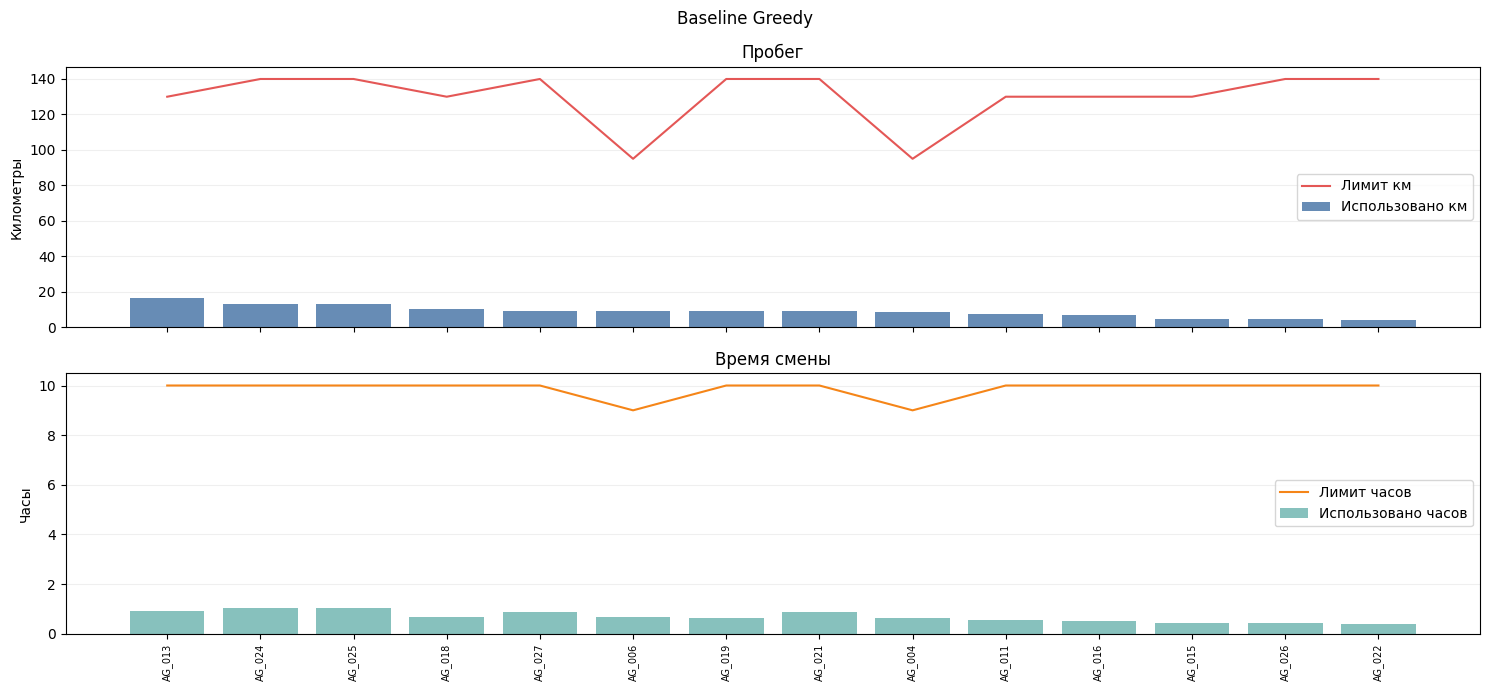

  Средняя загрузка км:    7.1%
  Средняя загрузка часов: 7.0%
  Нарушений км-лимита:    0

───────────────────────────────────────────────────────
  GAP-Lagrangean + VRP(NN+2opt) [step1=greedy]


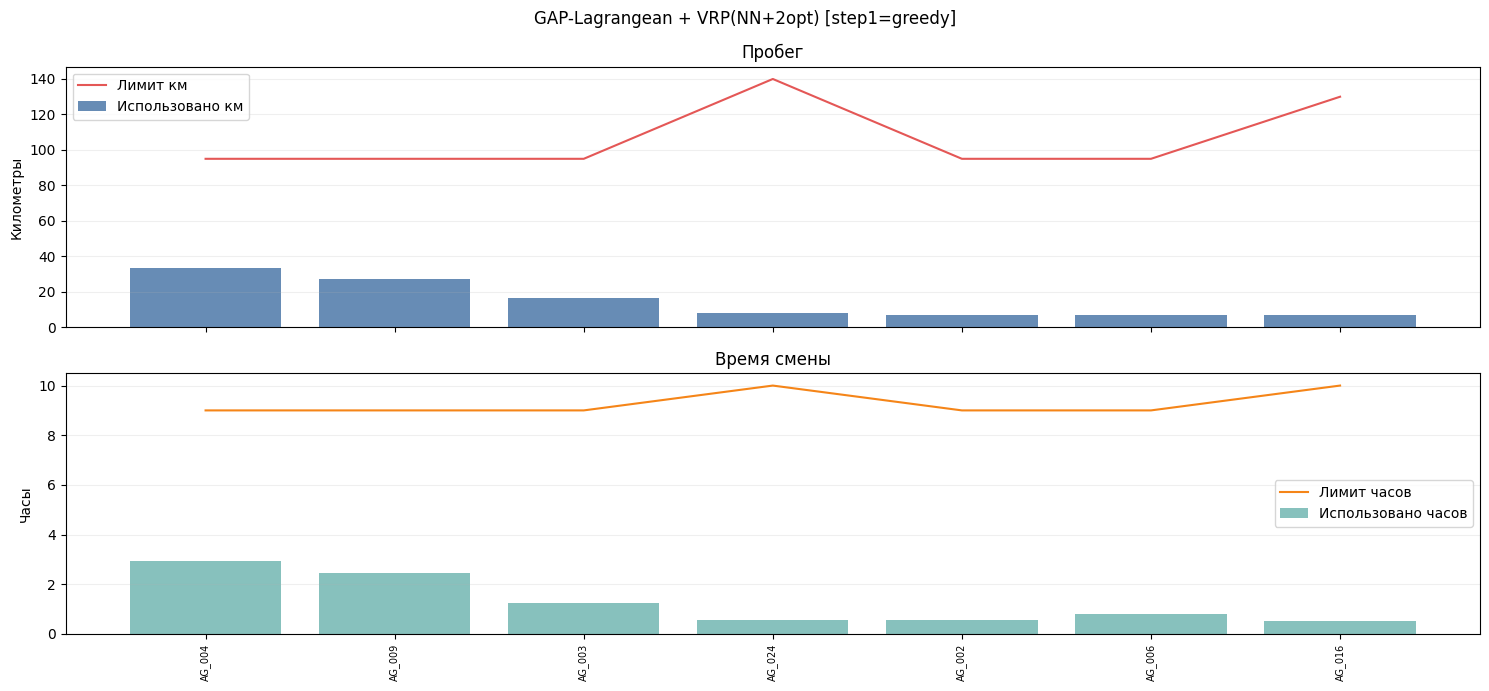

  Средняя загрузка км:    15.2%
  Средняя загрузка часов: 14.2%
  Нарушений км-лимита:    0

───────────────────────────────────────────────────────
  GAP-Lagrangean + VRP(NN+2opt) [step1=lp]


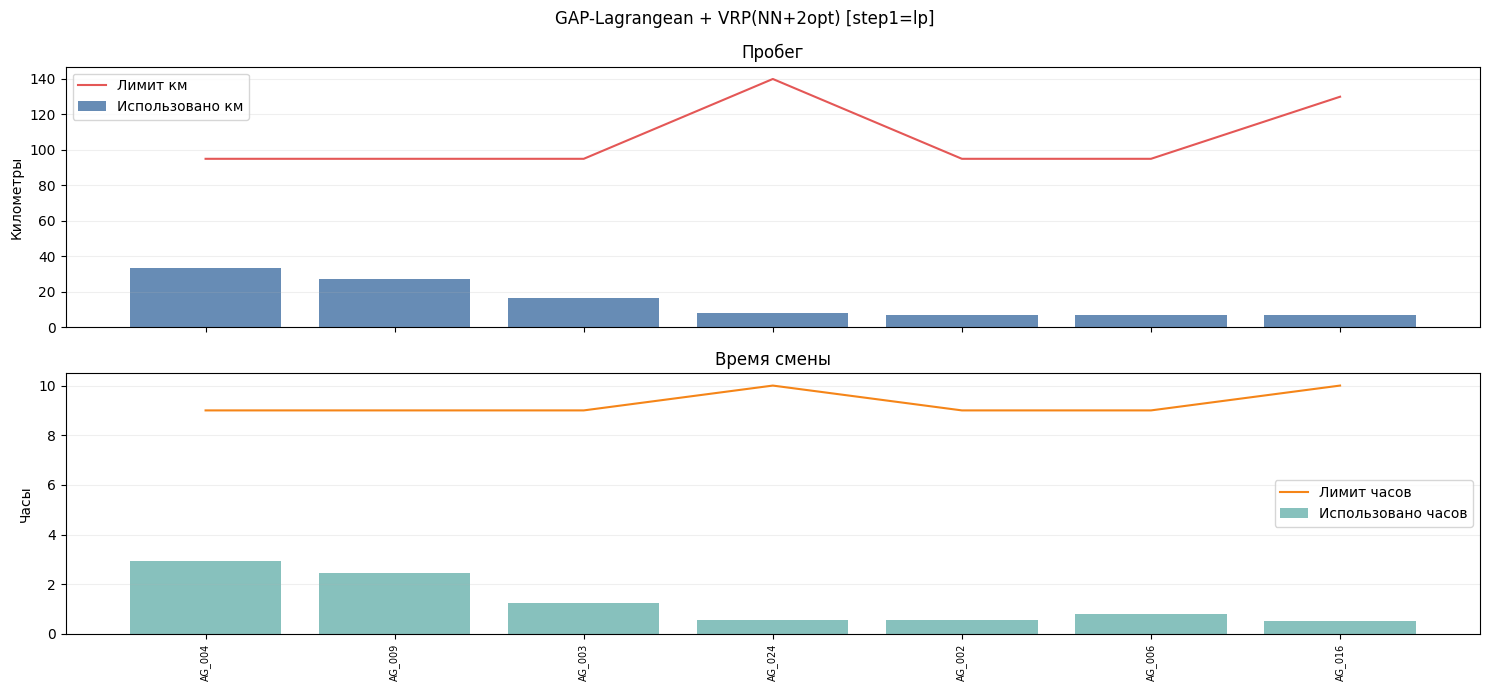

  Средняя загрузка км:    15.2%
  Средняя загрузка часов: 14.2%
  Нарушений км-лимита:    0


In [ ]:
def plot_agent_utilization(result: SolverResult, title: str) -> None:
    active = [s for s in result.states.values() if s.task_ids]
    if not active:
        print(f"  {title}: нет активных агентов")
        return

    active.sort(key=lambda s: s.total_km, reverse=True)
    names     = [s.agent_id for s in active]
    km_used   = [s.total_km for s in active]
    km_limits = [core.MAX_DAILY_KM_BY_TYPE[s.vehicle_type] for s in active]
    h_used    = [s.total_hours for s in active]
    h_limits  = [core.MAX_SHIFT_HOURS_BY_TYPE[s.vehicle_type] for s in active]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    fig.suptitle(title, fontsize=12)

    bars1 = ax1.bar(names, km_used, color="#4C78A8", alpha=0.85, label="Использовано км")
    ax1.plot(names, km_limits, color="#E45756", lw=1.5, label="Лимит км", zorder=3)
    ax1.set_ylabel("Километры")
    ax1.set_title("Пробег")
    ax1.legend()
    ax1.grid(axis="y", alpha=0.2)


    for i, (used, lim) in enumerate(zip(km_used, km_limits)):
        if used > lim + 1e-6:
            bars1[i].set_color("#E45756")

    ax2.bar(names, h_used, color="#72B7B2", alpha=0.85, label="Использовано часов")
    ax2.plot(names, h_limits, color="#F58518", lw=1.5, label="Лимит часов", zorder=3)
    ax2.set_ylabel("Часы")
    ax2.set_title("Время смены")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.2)

    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels(names, rotation=90, fontsize=7)

    plt.tight_layout()
    plt.show()

    km_util = [u / l * 100 for u, l in zip(km_used, km_limits) if l > 0]
    h_util  = [u / l * 100 for u, l in zip(h_used,  h_limits)  if l > 0]
    n_km_viol = sum(1 for u, l in zip(km_used, km_limits) if u > l + 1e-6)
    print(f"  Средняя загрузка км:    {sum(km_util)/len(km_util):.1f}%")
    print(f"  Средняя загрузка часов: {sum(h_util)/len(h_util):.1f}%")
    print(f"  Нарушений км-лимита:    {n_km_viol}")


for res in all_results:
    print(f"\n{'─'*55}")
    print(f"  {res.method_label}")
    plot_agent_utilization(res, res.method_label)

**Визуализация!!**

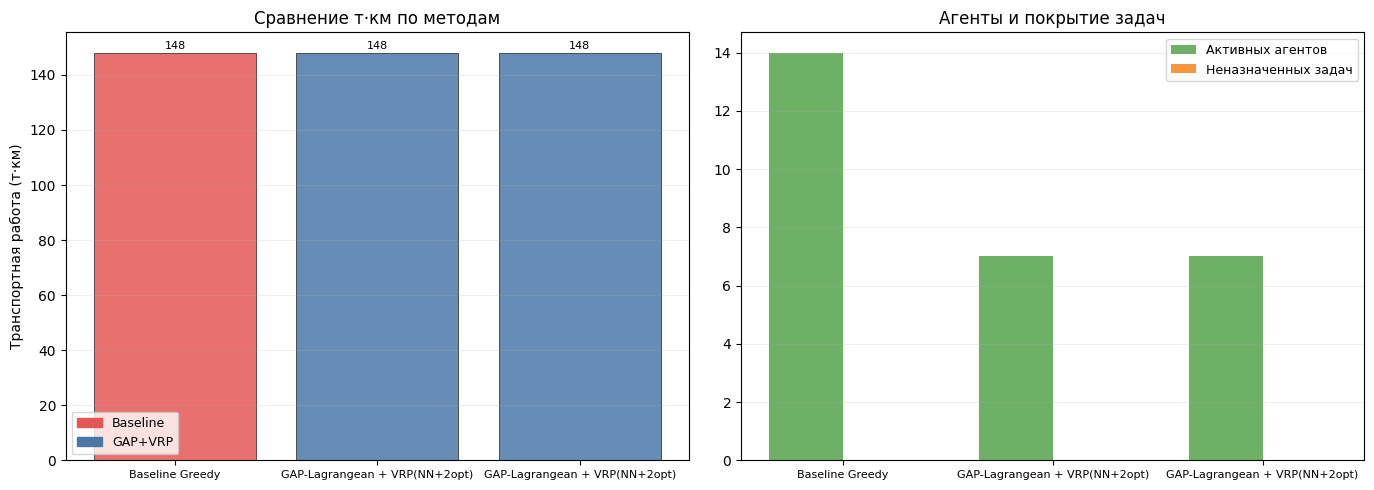

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
labels = [r.method_label.split(" [")[0] for r in all_results]
trkm   = [r.transport_work_ton_km or 0 for r in all_results]
colors = ["#E45756" if "Baseline" in l else "#4C78A8" for l in labels]

bars = ax.bar(range(len(labels)), trkm, color=colors, alpha=0.85, edgecolor="k", linewidth=0.5)
for i, (bar, val) in enumerate(zip(bars, trkm)):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(trkm) * 0.005,
                f"{val:.0f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f"\n".join(l.split(": ")) for l in labels], fontsize=8)
ax.set_ylabel("Транспортная работа (т·км)")
ax.set_title("Сравнение т·км по методам")
ax.grid(axis="y", alpha=0.2)
patches = [
    mpatches.Patch(color="#E45756", label="Baseline"),
    mpatches.Patch(color="#4C78A8", label="GAP+VRP"),
]
ax.legend(handles=patches, fontsize=9)

ax2 = axes[1]
x = np.arange(len(labels))
width = 0.35
active_list  = [r.active_agents    for r in all_results]
unassgn_list = [r.n_unassigned     for r in all_results]

b1 = ax2.bar(x - width/2, active_list,  width, label="Активных агентов", color="#54A24B", alpha=0.85)
b2 = ax2.bar(x + width/2, unassgn_list, width, label="Неназначенных задач", color="#F58518", alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f"\n".join(l.split(": ")) for l in labels], fontsize=8)
ax2.set_title("Агенты и покрытие задач")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

**Карта!!!**

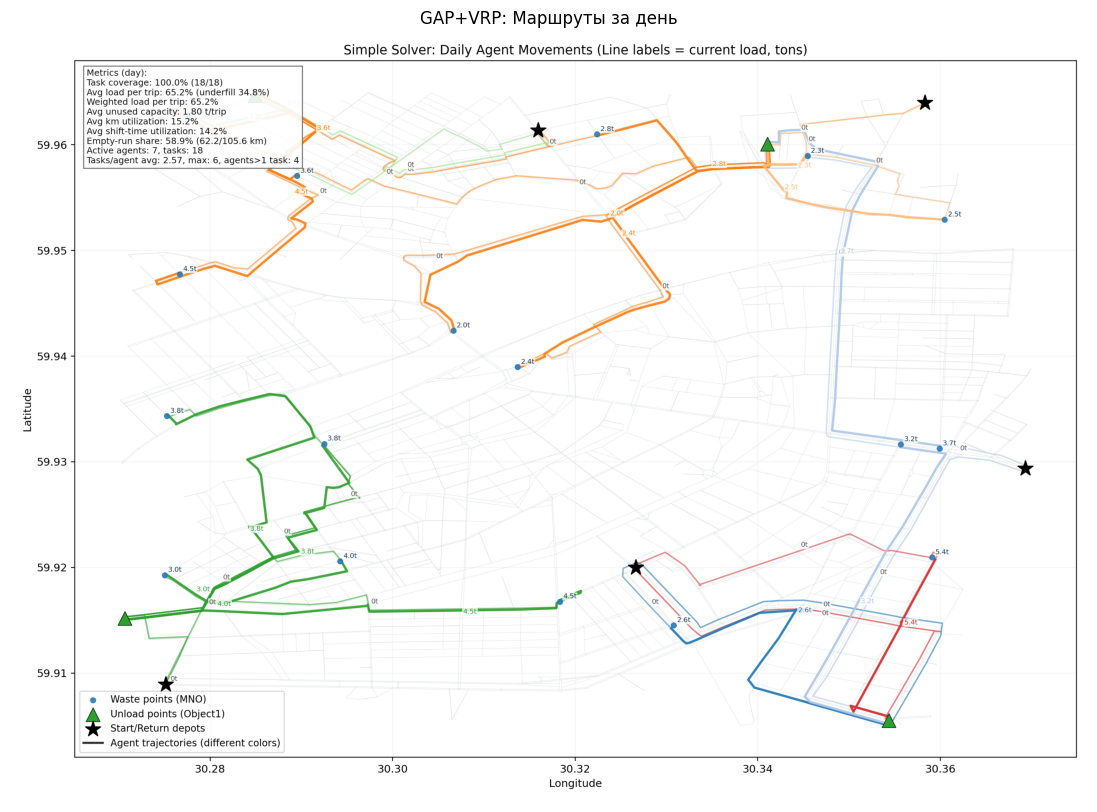

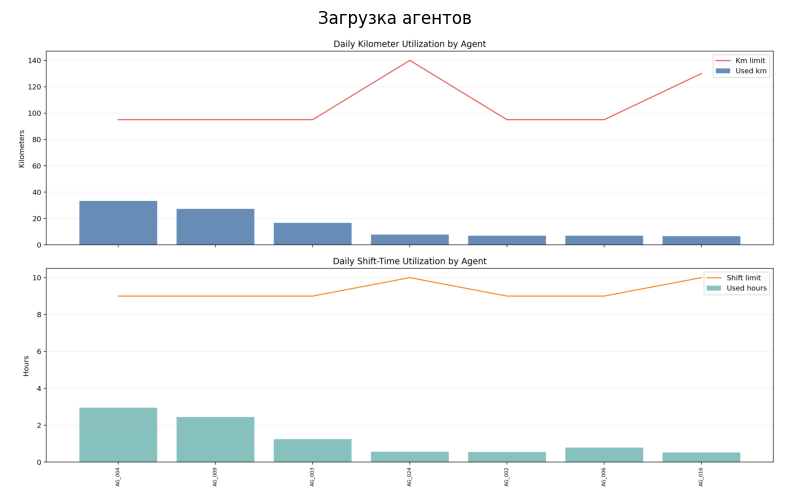

In [20]:
OUTPUT_DIR = NOTEBOOK_DIR / "gap_vrp_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
map_dir = OUTPUT_DIR / "day_001"
map_dir.mkdir(exist_ok=True)

if res_gap_lp.routes:
    used_task_ids = {tid for r in res_gap_lp.routes for tid in r.task_ids}
    
    from gap_vrp_solver import generate_tasks_lp
    lp_tasks = generate_tasks_lp(dataset, graph, cache)
    lp_tasks_used = [t for t in lp_tasks if t.task_id in used_task_ids]

    from dataset import RoutingDataset, RoadGraph, AgentsFleet
    render_dataset = RoutingDataset(
        graph=dataset.graph,
        fleet=dataset.fleet,
        tasks=lp_tasks_used,
        routes=res_gap_lp.routes,
        metadata=dataset.metadata,
    )

    core.render_solution_map(
        render_dataset, graph, cache,
        res_gap_lp.routes, res_gap_lp.states,
        map_dir / "solution_map.png",
    )
    core.render_utilization(res_gap_lp.states, map_dir / "utilization.png")

    import matplotlib.image as mpimg
    img = mpimg.imread(map_dir / "solution_map.png")
    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("GAP+VRP: Маршруты за день")
    plt.show()

    img2 = mpimg.imread(map_dir / "utilization.png")
    plt.figure(figsize=(15, 6))
    plt.imshow(img2)
    plt.axis("off")
    plt.title("Загрузка агентов")
    plt.show()
else:
    print("  Нет маршрутов для рендеринга")